In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 9.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [14]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import Dataset


In [15]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import Dataset


In [16]:
# 1. CONFIGURATION
MODEL_NAME = "roberta-base"
NUM_LABELS = 2
BATCH_SIZE = 16
LR         = 2e-5
EPOCHS     = 3
MAX_LEN    = 128
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU if available, else CPU


In [43]:
# 2. LOAD DATA
df = pd.read_csv("train.csv")

# 3. SPLIT TRAIN/VAL
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df.target,
    random_state=43
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)


In [44]:
# 4. TOKENIZER & MODEL
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
).to(DEVICE)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
# 5. CONVERT TO 🤗 datasets.Dataset
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)


In [46]:
# 6. TOKENIZATION FUNCTION
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN
    )


In [47]:
# 7. APPLY TOKENIZATION
train_ds = train_ds.map(tokenize_batch, batched=True, remove_columns=["text", "id"])
val_ds   = val_ds.map(tokenize_batch, batched=True, remove_columns=["text", "id"])


Map:   0%|          | 0/6851 [00:00<?, ? examples/s]

Map:   0%|          | 0/762 [00:00<?, ? examples/s]

In [48]:
# 8. RENAME LABEL COLUMN & SET FORMAT
train_ds = train_ds.rename_column("target", "labels")
val_ds   = val_ds.rename_column("target", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


In [49]:
# 9. DATALOADERS
collator     = DataCollatorWithPadding(tokenizer)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collator)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)


In [50]:

# 10. OPTIMIZER & SCHEDULER
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [51]:
# 11. TRACK METRICS
train_acc_list = []
val_acc_list   = []


Epoch 1/3:   0%|          | 0/429 [00:00<?, ?it/s]

[Epoch 1] loss: 0.4756 | train_accuracy: 0.7717
[Epoch 1] validation_accuracy: 0.8150


Epoch 2/3:   0%|          | 0/429 [00:00<?, ?it/s]

[Epoch 2] loss: 0.3439 | train_accuracy: 0.8596
[Epoch 2] validation_accuracy: 0.8163


Epoch 3/3:   0%|          | 0/429 [00:00<?, ?it/s]

[Epoch 3] loss: 0.2684 | train_accuracy: 0.8965
[Epoch 3] validation_accuracy: 0.8294


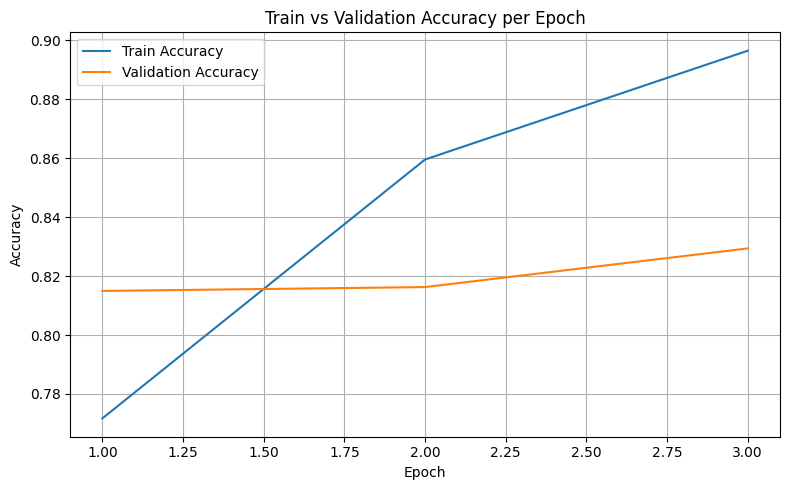

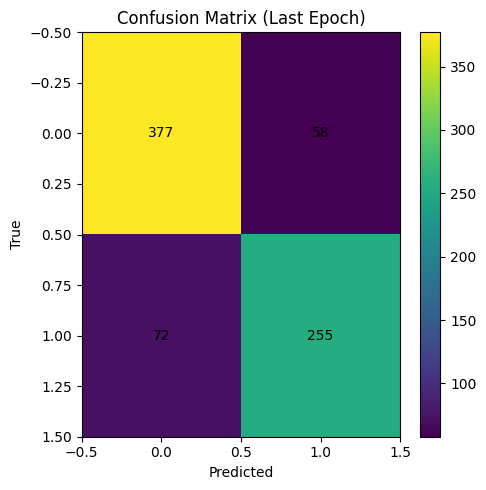

In [52]:
# 12. TRAINING LOOP
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    correct_train = 0
    total_train   = 0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for batch in progress:
        # نقل البيانات إلى DEVICE
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        # حساب دقة التدريب للـ batch
        preds = torch.argmax(outputs.logits, dim=-1)
        correct_train += (preds == batch['labels']).sum().item()
        total_train   += batch['labels'].size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        progress.set_postfix(loss=epoch_loss / (progress.n + 1))

    # حساب متوسط الخسارة ودقة التدريب
    avg_loss = epoch_loss / len(train_loader)
    train_acc = correct_train / total_train
    train_acc_list.append(train_acc)
    print(f"[Epoch {epoch+1}] loss: {avg_loss:.4f} | train_accuracy: {train_acc:.4f}")

    # تقييم على مجموعة التحقق لحساب دقة الفاليديشن لكل إبوك
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    val_acc_list.append(val_acc)
    print(f"[Epoch {epoch+1}] validation_accuracy: {val_acc:.4f}")
    model.train()

# 13. رسم مسار الدقة عبر الإبوكسي
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_acc_list, label='Train Accuracy')
plt.plot(range(1, EPOCHS+1), val_acc_list,   label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 14. CONFUSION MATRIX لآخر إبوك
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation="nearest", aspect="auto")
plt.title("Confusion Matrix (Last Epoch)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

# 15. دالة التنبؤ بتويتة جديدة

def predict(text):
    model.eval()
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred = torch.argmax(logits, dim=-1).item()
    return pred



In [53]:
# 16. مثال تفاعلي
if __name__ == "__main__":
    tweet = input("Enter a tweet: ")
    label = predict(tweet)
    print(f"Prediction (0=non-offensive, 1=offensive): {label}")

Enter a tweet: Huge wildfire raging through the hills outside my town — evacuations underway and smoke everywhere
Prediction (0=non-offensive, 1=offensive): 1


In [54]:
# 16. مثال تفاعلي
if __name__ == "__main__":
    tweet = input("Enter a tweet: ")
    label = predict(tweet)
    print(f"Prediction (0=non-offensive, 1=offensive): {label}")

Enter a tweet: Spent the afternoon reading a great book in the park and enjoying the sunshine.
Prediction (0=non-offensive, 1=offensive): 0
